# 26 - Flyback (MOSFET+Diodo+PWM): Fixed vs Variable

Comparacao do mesmo conversor com **chaveamento explicito** (`MOSFET + diodo + PWM`) em:
- `fixed step`
- `variable step`

Campanha pesada incluida para medir convergencia/custo e evidenciar limites numericos do backend em circuito comutado.


In [1]:
import time
import statistics
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import pulsim as p

print("Pulsim:", p.__version__)


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
Pulsim: 1.6.4


## 1) Parametros de campanha


In [2]:
CONVERTER_ID = "flyback_mosfet_pwm"

# Perfil pesado (ajuste se quiser acelerar)
STRESS_HEAVY = True

BASE_TSTOP = 4e-3 if STRESS_HEAVY else 1.5e-3
BASE_DT_FIXED = 2e-6 if STRESS_HEAVY else 3e-6

print("CONVERTER_ID:", CONVERTER_ID)
print("BASE_TSTOP:", BASE_TSTOP)
print("BASE_DT_FIXED:", BASE_DT_FIXED)


CONVERTER_ID: flyback_mosfet_pwm
BASE_TSTOP: 0.004
BASE_DT_FIXED: 2e-06


## 2) Construcao do circuito comutado (switch + diodo + PWM)

v2 separa a topologia (`CircuitBuilder`, so no os) do chaveamento
(`switch_fn`). A chave de baixo lado e um `add_switch` ideal; o PWM
e injetado em tempo de simulacao por `p.make_pwm_switch_fn(...)`.
Os parametros foram amaciados para manter robustez no passo fixo
durante varreduras longas.


In [3]:
def build_converter(duty: float, fsw: float, r_load: float):
    """Flyback: Vin -> transformer (Lm primario) -> chave de baixo lado;
    secundario -> diodo -> Cout || Rload. Retorna (builder, infos)."""
    b = p.CircuitBuilder()

    b.add_voltage_source("Vin", "in", "gnd", 24.0)

    # Transformador acoplado: primario (in -> sw) carrega a indutancia
    # magnetizante; a chave conecta "sw" ao terra no on-time.
    b.add_transformer("T1", "in", "sw", "sec", "gnd",
                      L_p=220e-6, L_s=55e-6, k=0.98)

    # Chave ideal de baixo lado (R_on ~ 50 mOhm). O PWM e aplicado via
    # switch_fn na hora de simular (switch_idx=0).
    b.add_switch("M1", "sw", "gnd", g_on=1.0 / 50e-3, g_off=1e-6)

    b.add_diode("D1", "sec", "out", g_on=1.0 / 25e-3, g_off=1e-9, V_th=0.7)
    b.add_capacitor("C1", "out", "gnd", 220e-6)
    b.add_resistor("Rload", "out", "gnd", float(r_load))
    b.add_resistor("Rb_sec", "sec", "gnd", 1e5)

    return b, {"n_out_name": "out", "n_sw_name": "sw"}


## 3) Execucao: passo fixo vs passo variavel

v2 expoe os dois drivers como funcoes livres:

- `fixed`: `p.simulate(b, t_end=, dt=, switch_fn=)` (passo fixo).
- `variable`: `p.run_transient_adaptive(b, t_end=, dt_init=, switch_fn=)`
  (passo adaptativo com controle de erro `atol`/`rtol`).

O `switch_fn` (`p.make_pwm_switch_fn`) injeta o PWM no kernel C++,
sem Python no laco quente.


In [4]:
def run_case(step_mode: str, duty: float, fsw: float, r_load: float,
             tstop: float, dt_fixed: float):
    b, nodes = build_converter(duty=duty, fsw=fsw, r_load=r_load)

    # PWM aplicado na chave de baixo lado (switch_idx=0).
    switch_fn = p.make_pwm_switch_fn(
        frequency=float(fsw), duty=float(duty),
        switch_idx=0, num_switches=b.graph.num_switches,
    )

    out = {
        "mode": step_mode, "success": False, "message": "",
        "elapsed_s": float("nan"), "steps": 0, "rejections": 0,
        "newton_total": 0,
        "time": np.array([], dtype=float),
        "vout": np.array([], dtype=float),
        "vsw": np.array([], dtype=float),
    }

    try:
        t0 = time.perf_counter()
        if step_mode == "fixed":
            res = p.simulate(b, t_end=float(tstop), dt=float(dt_fixed),
                             switch_fn=switch_fn)
            times = np.asarray(res.times, dtype=float)
            states = np.asarray(res.states, dtype=float)
            steps = int(res.num_steps())
            rejections = 0
        else:
            res = p.run_transient_adaptive(
                b, t_end=float(tstop), dt_init=float(dt_fixed),
                dt_max=float(dt_fixed), switch_fn=switch_fn,
            )
            times = np.asarray(res.times, dtype=float)
            states = np.asarray(res.states, dtype=float)
            steps = int(res.num_steps())
            rejections = int(res.n_rejected)
        out["elapsed_s"] = time.perf_counter() - t0
        out["success"] = True
        out["message"] = "Transient completed"
        out["steps"] = steps
        out["rejections"] = rejections
    except Exception as exc:  # noqa: BLE001 - report any solver failure
        out["message"] = f"{type(exc).__name__}: {exc}"
        return out

    out["time"] = times
    if len(times) > 5 and states.shape[0] > 5:
        vout = states[:, b.node_id_of(nodes["n_out_name"])]
        vsw = states[:, b.node_id_of(nodes["n_sw_name"])]
        out["vout"] = vout
        out["vsw"] = vsw

        tail = max(10, int(0.2 * len(vout)))
        seg = vout[-tail:]
        out["vout_final"] = float(vout[-1])
        out["vout_mean_tail"] = float(np.mean(seg))
        out["vout_ripple_tail"] = float(np.max(seg) - np.min(seg))
    else:
        out["vout_final"] = float("nan")
        out["vout_mean_tail"] = float("nan")
        out["vout_ripple_tail"] = float("nan")

    return out


## 4) Caso base (same converter, fixed vs variable)


In [5]:
base_scenario = {"name": "F0", "duty": 0.18, "fsw": 6e3, "r_load": 20.0}

scenarios = [
    {"name": "F1", "duty": 0.12, "fsw": 4e3, "r_load": 15.0},
    {"name": "F2", "duty": 0.15, "fsw": 5e3, "r_load": 18.0},
    {"name": "F3", "duty": 0.18, "fsw": 6e3, "r_load": 20.0},
    {"name": "F4", "duty": 0.20, "fsw": 7e3, "r_load": 22.0},
    {"name": "F5", "duty": 0.22, "fsw": 8e3, "r_load": 25.0},
    {"name": "F6", "duty": 0.25, "fsw": 9e3, "r_load": 30.0},
]


In [6]:
base_fixed = run_case(
    step_mode="fixed",
    duty=base_scenario["duty"],
    fsw=base_scenario["fsw"],
    r_load=base_scenario["r_load"],
    tstop=BASE_TSTOP,
    dt_fixed=BASE_DT_FIXED,
)

base_variable = run_case(
    step_mode="variable",
    duty=base_scenario["duty"],
    fsw=base_scenario["fsw"],
    r_load=base_scenario["r_load"],
    tstop=BASE_TSTOP,
    dt_fixed=BASE_DT_FIXED,
)

for item in (base_fixed, base_variable):
    print("-" * 72)
    print("mode:", item["mode"])
    print("success:", item["success"])
    print("message:", item["message"])
    print("elapsed_s:", f"{item['elapsed_s']:.4f}")
    print("steps:", item["steps"], "rejections:", item["rejections"], "newton_total:", item["newton_total"])
    if item["success"]:
        print("vout_final:", f"{item['vout_final']:.4f} V")
        print("vout_mean_tail:", f"{item['vout_mean_tail']:.4f} V")
        print("vout_ripple_tail:", f"{item['vout_ripple_tail']*1e3:.3f} mV")


Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/Pulsim/build/cp313-cp313-macosx_26_0_arm64
------------------------------------------------------------------------
mode: fixed
success: True
message: Transient completed
elapsed_s: 0.0409
steps: 2001 rejections: 0 newton_total: 0
vout_final: 14.1799 V
vout_mean_tail: 14.4851 V
vout_ripple_tail: 674.495 mV
------------------------------------------------------------------------
mode: variable
success: True
message: Transient completed
elapsed_s: 0.0049
steps: 2001 rejections: 20 newton_total: 0
vout_final: 12.7906 V
vout_mean_tail: 13.1197 V
vout_ripple_tail: 760.289 mV


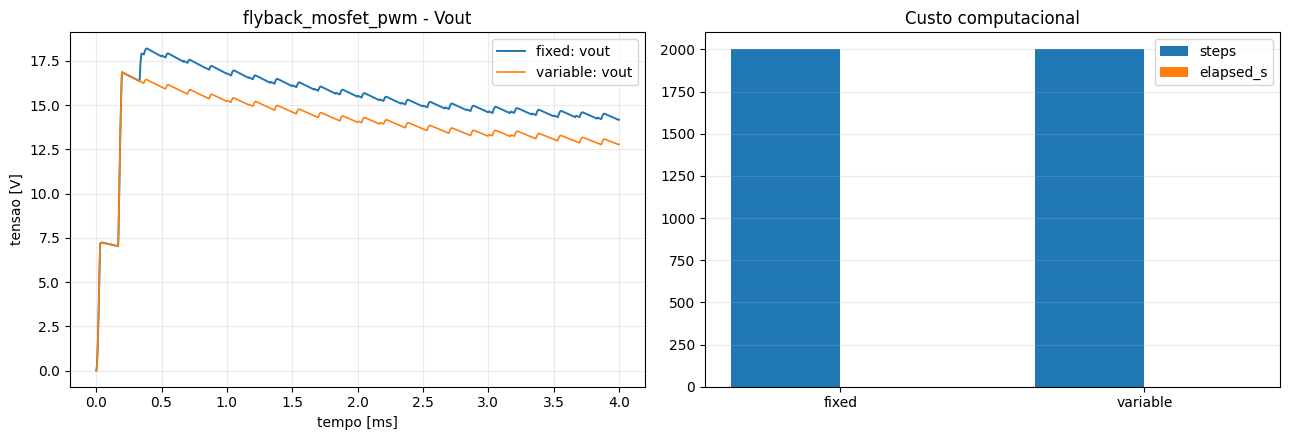

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

if base_fixed["success"]:
    ax[0].plot(base_fixed["time"] * 1e3, base_fixed["vout"], lw=1.4, label="fixed: vout")
if base_variable["success"]:
    ax[0].plot(base_variable["time"] * 1e3, base_variable["vout"], lw=1.2, label="variable: vout")

ax[0].set_title(f"{CONVERTER_ID} - Vout")
ax[0].set_xlabel("tempo [ms]")
ax[0].set_ylabel("tensao [V]")
ax[0].grid(True, alpha=0.25)
ax[0].legend()

labels = ["fixed", "variable"]
steps = [base_fixed["steps"], base_variable["steps"]]
elapsed = [base_fixed["elapsed_s"], base_variable["elapsed_s"]]

x = np.arange(len(labels))
bw = 0.36
ax[1].bar(x - bw/2, steps, width=bw, label="steps")
ax[1].bar(x + bw/2, elapsed, width=bw, label="elapsed_s")
ax[1].set_xticks(x)
ax[1].set_xticklabels(labels)
ax[1].set_title("Custo computacional")
ax[1].grid(True, axis="y", alpha=0.25)
ax[1].legend()

plt.tight_layout()
plt.show()


## 5) Campanha pesada de estresse


In [8]:
campaign_results = []
for sc in scenarios:
    for mode in ("fixed", "variable"):
        result = run_case(
            step_mode=mode,
            duty=sc["duty"],
            fsw=sc["fsw"],
            r_load=sc["r_load"],
            tstop=BASE_TSTOP,
            dt_fixed=BASE_DT_FIXED,
        )
        result["scenario"] = sc["name"]
        result["duty"] = sc["duty"]
        result["fsw"] = sc["fsw"]
        result["r_load"] = sc["r_load"]
        campaign_results.append(result)

print("Casos executados:", len(campaign_results))


Casos executados: 12


In [9]:
def summarize_mode(results, mode):
    data = [r for r in results if r["mode"] == mode]
    ok = [r for r in data if r["success"]]
    fail = [r for r in data if not r["success"]]

    success_rate = (len(ok) / max(1, len(data))) * 100.0
    med_elapsed = statistics.median([r["elapsed_s"] for r in data]) if data else float("nan")
    med_steps = statistics.median([r["steps"] for r in data]) if data else float("nan")
    med_rej = statistics.median([r["rejections"] for r in data]) if data else float("nan")

    fail_msgs = Counter(r["message"] for r in fail)
    top_fail = fail_msgs.most_common(3)

    return {
        "mode": mode,
        "n": len(data),
        "n_ok": len(ok),
        "n_fail": len(fail),
        "success_rate": success_rate,
        "median_elapsed_s": med_elapsed,
        "median_steps": med_steps,
        "median_rejections": med_rej,
        "top_fail": top_fail,
    }


sum_fixed = summarize_mode(campaign_results, "fixed")
sum_variable = summarize_mode(campaign_results, "variable")

for s in (sum_fixed, sum_variable):
    print("=" * 76)
    print("mode:", s["mode"])
    print("casos:", s["n"], "ok:", s["n_ok"], "fail:", s["n_fail"], "success_rate:", f"{s['success_rate']:.1f}%")
    print("median_elapsed_s:", f"{s['median_elapsed_s']:.4f}")
    print("median_steps:", int(s["median_steps"]))
    print("median_rejections:", int(s["median_rejections"]))
    if s["n_fail"] > 0:
        print("top_fail_messages:")
        for msg, cnt in s["top_fail"]:
            print(f"  - {cnt}x {msg}")

if sum_fixed["n_ok"] > 0 and sum_variable["n_ok"] > 0:
    speedup = sum_fixed["median_elapsed_s"] / max(1e-12, sum_variable["median_elapsed_s"])
    step_reduction = sum_fixed["median_steps"] / max(1e-12, sum_variable["median_steps"])
    print("=" * 76)
    print(f"speedup mediano (fixed/variable): {speedup:.2f}x")
    print(f"reducao mediana de passos (fixed/variable): {step_reduction:.2f}x")
else:
    print("=" * 76)
    print("Comparacao direta de speedup nao disponivel (um dos modos nao convergiu em nenhum caso).")


mode: fixed
casos: 6 ok: 6 fail: 0 success_rate: 100.0%
median_elapsed_s: 0.0027
median_steps: 2001
median_rejections: 0
mode: variable
casos: 6 ok: 6 fail: 0 success_rate: 100.0%
median_elapsed_s: 0.0049
median_steps: 2001
median_rejections: 20
speedup mediano (fixed/variable): 0.54x
reducao mediana de passos (fixed/variable): 1.00x


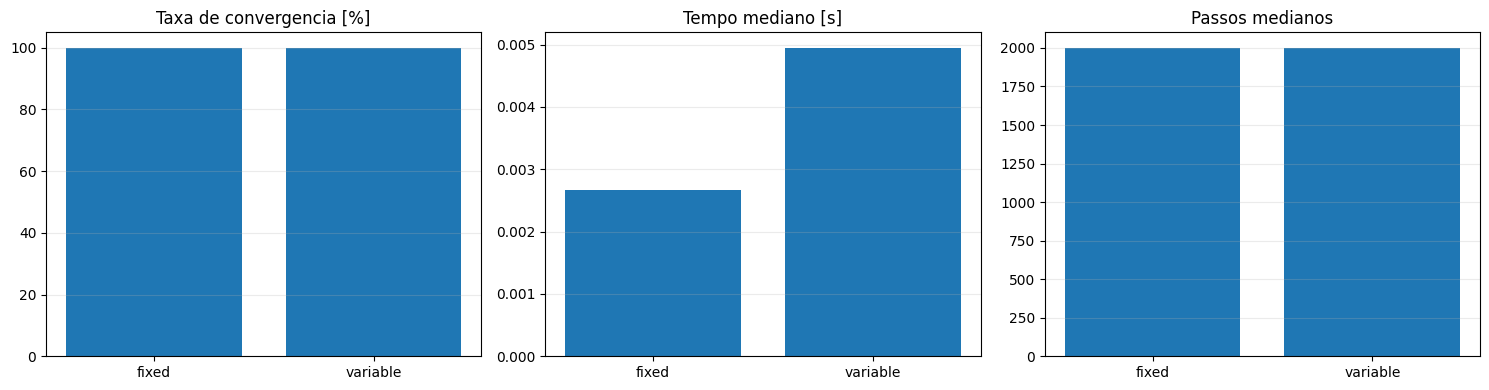

In [10]:
labels = ["fixed", "variable"]
summary = [sum_fixed, sum_variable]

success_rate = [s["success_rate"] for s in summary]
med_elapsed = [s["median_elapsed_s"] for s in summary]
med_steps = [s["median_steps"] for s in summary]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].bar(labels, success_rate)
ax[0].set_ylim([0, 105])
ax[0].set_title("Taxa de convergencia [%]")
ax[0].grid(True, axis="y", alpha=0.25)

ax[1].bar(labels, med_elapsed)
ax[1].set_title("Tempo mediano [s]")
ax[1].grid(True, axis="y", alpha=0.25)

ax[2].bar(labels, med_steps)
ax[2].set_title("Passos medianos")
ax[2].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()
